<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_1_Aprendizaje_Estadistico_Analisis_Descriptivo/blob/main/Sanchez_Jeisson_y_Bogota_Juan_CasoEstudio_sesion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de estudio integrador - Sesión 1**
### **RutaExpress: análisis descriptivo de una operación de última milla**
**Estudiantes:** *Jeisson David Sanchez & Juan Daniel Bogotá*


## **1. Contexto de negocio**

RutaExpress es una startup de entregas de última milla (last-mile delivery) que acaba de cerrar una ronda de inversión Serie A. Opera con una flota mixta de bicicletas, motocicletas, automóviles y, de forma piloto, drones de reparto en algunas zonas de la ciudad.

La Dirección de Operaciones te contrata como analista de datos para responder, con evidencia estadística, tres preguntas que están sobre la mesa del comité directivo:
* ¿Vale la pena invertir en expandir la flota de drones más allá del piloto
actual?
* ¿Qué zona de la ciudad requiere una intervención operativa prioritaria?
* ¿Qué meta de tiempo de entrega (SLA) es razonable comunicar públicamente a los clientes, sin comprometer la reputación de la marca?

Para resolverlas, el equipo de operaciones te compartió un extracto de 1,500 envíos recientes con información de zona, vehículo, nivel de servicio, distancia, peso, tiempo de entrega, incidencias, calificación del cliente y costo.


## **2. Diccionario de datos**
La siguiente tabla describe cada variable del dataset. Nota que, deliberadamente, no se incluye una columna de "tipo de variable": clasificarlas es parte de tu trabajo en la Parte A.

| Variable                | Descripción                                                                                                | Unidad / Categorías                     |
| ----------------------- | ---------------------------------------------------------------------------------------------------------- | --------------------------------------- |
| envio_id                | Identificador único del envío                                                                              | Numérico secuencial (no analizar)       |
| zona_entrega            | Zona de la ciudad donde se entregó el paquete                                                              | Centro, Norte, Sur, Poniente, Oriente   |
| tipo_vehiculo           | Vehículo usado para realizar la entrega                                                                    | Bicicleta, Motocicleta, Automóvil, Dron |
| nivel_servicio          | Nivel de servicio contratado por el cliente                                                                | Estándar, Prioritario, Express          |
| distancia_km            | Distancia recorrida entre el centro de distribución y el destino                                           | Kilómetros                              |
| peso_paquete_kg         | Peso del paquete entregado                                                                                 | Kilogramos                              |
| tiempo_entrega_min      | Tiempo total transcurrido desde que el paquete sale del centro de distribución hasta que llega al cliente  | Minutos                                 |
| paquetes_repartidor_dia | Número de paquetes que entregó ese repartidor durante el día del envío                                     | Conteo de paquetes                      |
| incidencias_reportadas  | Número de incidencias registradas durante ese envío (tráfico, dirección incorrecta, cliente ausente, etc.) | Conteo de incidencias                   |
| calificacion_cliente    | Calificación que el cliente dio al servicio recibido                                                       | Escala de 1 a 5 estrellas               |
| costo_envio_mxn         | Costo total cobrado al cliente por el envío                                                                | Pesos mexicanos (MXN)                   |


## **3. Generación de los datos**


In [2]:
import numpy as np
import pandas as pd

np.random.seed(2026)
n_envios = 1500

zona_entrega = np.random.choice(
    ["Centro", "Norte", "Sur", "Poniente", "Oriente"],
    size=n_envios, p=[0.30, 0.20, 0.20, 0.15, 0.15]
)

tipo_vehiculo = np.random.choice(
    ["Bicicleta", "Motocicleta", "Automóvil", "Dron"],
    size=n_envios, p=[0.30, 0.40, 0.25, 0.05]
)

nivel_servicio = np.random.choice(
    ["Estándar", "Prioritario", "Express"],
    size=n_envios, p=[0.55, 0.30, 0.15]
)

distancia_km = np.random.gamma(shape=3.0, scale=1.8, size=n_envios).round(2)
peso_paquete_kg = np.random.gamma(shape=2.0, scale=1.1, size=n_envios).round(2)
paquetes_repartidor_dia = np.random.poisson(lam=14, size=n_envios)
incidencias_reportadas = np.random.poisson(lam=0.4, size=n_envios)

calificacion_cliente = np.random.choice(
    [1, 2, 3, 4, 5], size=n_envios, p=[0.03, 0.07, 0.15, 0.35, 0.40]
)

factor_vehiculo = pd.Series(tipo_vehiculo).map({
    "Bicicleta": 6.5, "Motocicleta": 3.8, "Automóvil": 4.5, "Dron": 2.0
}).values

tiempo_base = distancia_km * factor_vehiculo + np.random.normal(5, 3, n_envios)

factor_zona = pd.Series(zona_entrega).map({
    "Centro": 1.0, "Norte": 1.05, "Sur": 1.35, "Poniente": 1.1, "Oriente": 1.15
}).values

tiempo_entrega_min = tiempo_base * factor_zona
tiempo_entrega_min += incidencias_reportadas * np.random.uniform(15, 45, n_envios)
tiempo_entrega_min = np.clip(tiempo_entrega_min, 4, None).round(1)

costo_envio_mxn = (25 + distancia_km * 4.2 + peso_paquete_kg * 3.0 +
                    (nivel_servicio == "Express") * 35 +
                    (nivel_servicio == "Prioritario") * 15 +
                    np.random.normal(0, 5, n_envios)).round(2)
costo_envio_mxn = np.clip(costo_envio_mxn, 20, None)

df = pd.DataFrame({
    "envio_id": range(1, n_envios + 1),
    "zona_entrega": zona_entrega,
    "tipo_vehiculo": tipo_vehiculo,
    "nivel_servicio": nivel_servicio,
    "distancia_km": distancia_km,
    "peso_paquete_kg": peso_paquete_kg,
    "tiempo_entrega_min": tiempo_entrega_min,
    "paquetes_repartidor_dia": paquetes_repartidor_dia,
    "incidencias_reportadas": incidencias_reportadas,
    "calificacion_cliente": calificacion_cliente,
    "costo_envio_mxn": costo_envio_mxn,
})

df.head()

,envio_id,zona_entrega,tipo_vehiculo,nivel_servicio,distancia_km,peso_paquete_kg,tiempo_entrega_min,paquetes_repartidor_dia,incidencias_reportadas,calificacion_cliente,costo_envio_mxn
0,1,Centro,Motocicleta,Prioritario,0.83,2.33,56.9,16,1,5,52.76
1,2,Norte,Motocicleta,Estándar,10.26,2.87,83.7,14,1,4,72.46
2,3,Oriente,Automóvil,Estándar,2.08,3.54,15.6,11,0,5,51.37
3,4,Centro,Bicicleta,Prioritario,3.54,2.28,28.8,12,0,2,66.48
4,5,Norte,Automóvil,Estándar,5.54,1.74,32.2,13,0,5,51.92


## **Parte A — Conceptos y tipos de variable**


1.   **Clasifica cada una de las variables del dataset (tipo y subtipo: numérica continua/discreta, categórica nominal/ordinal).**

| Variable | Tipo | Subtipo |
|---|---|---|
| envio_id |  |  |
| zona_entrega | Categórica | Nominal |
| tipo_vehiculo | Categórica | Nominal |
| nivel_servicio | Categórica | Ordinal |
| distancia_km | Numérica | Continua |
| peso_paquete_kg | Numérica | Continua |
| tiempo_entrega_min | Numérica | Continua |
| paquetes_repartidor_dia | Numérica | Discreta |
| incidencias_reportadas | Numérica | Discreta |
| calificacion_cliente | Categórica | Ordinal |
| costo_envio_mxn | Numérica | Continua |

2.  **El equipo de sistemas de RutaExpress está considerando guardar nivel_servicio como un número (1 = Estándar, 2 = Prioritario, 3 = Express) para "ahorrar espacio" en la base de datos. Si un analista junior calculara el promedio de esa columna numérica y reportara "el nivel de servicio promedio es 1.6", ¿qué error de interpretación estaría cometiendo? ¿Qué sí sería válido hacer con esa codificación numérica y qué no?**

>Codificar nivel_servicio como 1 = Estándar, 2 = Prioritario, 3 = Express y luego calcular su promedio (1.6) sería un error, porque esos números representan un orden y no una categoria de servicio.

>Decir "el nivel de servicio promedio es 1.6" le da un significado numérico que no tiene, ya que la diferencia entre 1, 2 y 3 no es necesariamente la misma diferencia entre Estándar, Prioritario y Express.

>**Válido con esa codificación:**
- Ordenar los niveles (3 > 2 > 1)
- Calcular la moda (nivel más frecuente)

>**No válido con esa codificación:**
- Calcular la media o la desviación estándar de esa columna numérica
- Interpretar el resultado como si fuera una cantidad continua


## **Parte B — Medidas de tendencia central**


1. **Calcula la media, la mediana y la moda de tiempo_entrega_min. ¿Cuál de las tres describe mejor el tiempo "típico" de entrega? Explica por qué el equipo de Operaciones NO debería usar la media si quiere fijar una promesa de tiempo de entrega (SLA) al cliente.**






In [3]:
media_tiempo = df['tiempo_entrega_min'].mean()
mediana_tiempo = df['tiempo_entrega_min'].median()
moda_tiempo = df['tiempo_entrega_min'].mode()[0]

print(f"Media: {media_tiempo:.2f} min")
print(f"Mediana: {mediana_tiempo:.2f} min")
print(f"Moda: {moda_tiempo:.2f} min")

Media: 46.90 min
Mediana: 41.20 min
Moda: 21.70 min


- Media: 46.90 min
- Mediana: 41.20 min
- Moda: 21.70 min

>La mediana es la medida que mejor representa el tiempo de entrega típico. Aunque la media es de 46.90 minutos, está un poco por encima de la mediana (41.20 minutos), lo que indica que hay algunos pedidos que tardaron mucho más de lo normal y hacen que el promedio aumente. La diferencia entre ambas es de aproximadamente 5.7 minutos, lo que muestra que los datos tienen un sesgo hacia los tiempos más altos. Por otro lado, la moda fue de 21.70 minutos, pero como el tiempo de entrega es una variable continua, este valor no es muy representativo. Por eso, consideramos que la mediana es la mejor opción para establecer el SLA, ya que refleja de una forma más realista el tiempo que tarda la mayoría de las entregas y no se ve afectada por los valores atípicos.

2. **La Dirección General quiere anunciar públicamente "entregamos en X minutos" como parte de una campaña de marketing. Con base en tus resultados, ¿qué valor de X recomendarías y qué medida descriptiva sustenta tu recomendación?**

>Se recomienda establecer un valor de X = 41 minutos, ya que corresponde a la mediana del tiempo de entrega. Consideramos que esta es la mejor medida porque representa mejor el tiempo que realmente tarda la mayoría de los pedidos. La media es de 46.90 minutos, pero está influenciada por algunos envíos que tardaron mucho más de lo normal, haciendo que el promedio aumente. Si se usara la media para definir el SLA, se estaría comunicando un tiempo de entrega más alto del que normalmente reciben los clientes. En cambio, la mediana ofrece un valor más realista y consistente para establecer ese compromiso.



3. **Calcula la mediana de tiempo_entrega_min por tipo de vehículo. ¿Qué vehículo tiene el mejor desempeño de tiempos? Con ese resultado, ¿qué decisión operativa (por ejemplo, sobre el tamaño o composición de la flota) le propondrías al Director de Operaciones?**


In [4]:
mediana_por_vehiculo = df.groupby('tipo_vehiculo')['tiempo_entrega_min'].median().sort_values()
print(mediana_por_vehiculo)

tipo_vehiculo
Dron           19.75
Motocicleta    37.90
Automóvil      39.80
Bicicleta      54.30
Name: tiempo_entrega_min, dtype: float64


- Dron: 19.75 min
- Motocicleta: 37.90 min
- Automóvil: 39.80 min
- Bicicleta: 54.30 min

>El Dron es el vehículo con el mejor tiempo de entrega, ya que tiene una mediana de 19.75 minutos, siendo mucho menor que la de los demás medios de transporte. Esto demuestra que es la opción más rápida y que ampliar su uso en las zonas donde sea posible podría ayudar a reducir los tiempos de entrega. En cambio, la Bicicleta tiene la mediana más alta, con 54.30 minutos, por lo que es el vehículo con el menor rendimiento. Por esta razón, consideramos que sería conveniente limitar su uso a recorridos cortos o lugares donde no sea fácil acceder con otros vehículos, y darle mayor prioridad a las Motocicletas o Drones cuando las condiciones lo permitan.

## **Parte C — Medidas de dispersión**

1. **Calcula la desviación estándar y el coeficiente de variación de tiempo_entrega_min. En tus palabras: ¿qué tan consistente es el servicio de entrega de RutaExpress?**



In [5]:
desv_tiempo = df['tiempo_entrega_min'].std()
media_tiempo = df['tiempo_entrega_min'].mean()
cv_tiempo = (desv_tiempo / media_tiempo) * 100

print(f"Desviación estándar: {desv_tiempo:.2f} min")
print(f"Coeficiente de variación: {cv_tiempo:.1f}%")

Desviación estándar: 27.90 min
Coeficiente de variación: 59.5%


- Desviación estándar: 27.90 min
- Coeficiente de variación: 59.5%

>El servicio de entrega de RutaExpress no es muy consistente, ya que tiene un coeficiente de variación del 59.5%, lo que significa que los tiempos de entrega cambian bastante entre un pedido y otro. En otras palabras, un cliente puede recibir su pedido muy rápido en una ocasión y mucho más tarde en otra, incluso si las condiciones son parecidas.



2. **Compara el coeficiente de variación del tiempo de entrega entre las cinco zonas. Si una zona tiene una media de tiempo similar a las demás pero un coeficiente de variación notablemente más alto, ¿qué significa eso para la experiencia del cliente en esa zona, y qué acción operativa priorizarías ahí?**


In [6]:
cv_por_zona = df.groupby('zona_entrega')['tiempo_entrega_min'].agg(['mean', 'std'])
cv_por_zona['cv_%'] = (cv_por_zona['std'] / cv_por_zona['mean']) * 100
cv_por_zona = cv_por_zona.sort_values('cv_%', ascending=False)
print(cv_por_zona)

                   mean        std       cv_%
zona_entrega                                 
Norte         46.041176  28.909688  62.790940
Oriente       47.649791  28.133483  59.042196
Sur           52.934796  30.909210  58.391100
Centro        43.129356  25.167790  58.354200
Poniente      45.718433  25.126571  54.959388


| Zona | Media | Desv. estándar | CV (%) |
|---|---|---|---|
| Norte | 46.04 | 28.91 | 62.79 |
| Oriente | 47.65 | 28.13 | 59.04 |
| Sur | 52.93 | 30.91 | 58.39 |
| Centro | 43.13 | 25.17 | 58.35 |
| Poniente | 45.72 | 25.13 | 54.96 |

>La zona Norte es la que presenta el coeficiente de variación más alto (62.79%), aunque su tiempo promedio de entrega (46.04 minutos) es muy parecido al de las demás zonas. Esto significa que el problema no es que las entregas sean más lentas, sino que los tiempos varían mucho entre un pedido y otro. En algunos casos los pedidos llegan muy rápido y en otros tardan bastante más, lo que hace que el servicio sea poco predecible para los clientes. Por eso, consideramos que lo más importante es identificar qué está causando esa variación, como problemas de tráfico, incidencias en las rutas o diferencias en el desempeño de los repartidores. En cambio, si el problema fuera la lentitud, como ocurre en la zona Sur, sí tendría más sentido pensar en aumentar la flota de reparto.


3. **Calcula el coeficiente de variación de costo_envio_mxn para cada nivel de servicio (Estándar, Prioritario, Express). ¿El servicio Express es más o menos predecible en su costo que el Estándar? ¿Qué implicación tiene esto si RutaExpress quiere ofrecer un precio fijo garantizado por nivel de servicio?**

In [7]:
cv_por_nivel = df.groupby('nivel_servicio')['costo_envio_mxn'].agg(['mean', 'std'])
cv_por_nivel['cv_%'] = (cv_por_nivel['std'] / cv_por_nivel['mean']) * 100
cv_por_nivel = cv_por_nivel.sort_values('cv_%', ascending=False)
print(cv_por_nivel)

                     mean        std       cv_%
nivel_servicio                                 
Estándar        54.838743  14.990524  27.335645
Prioritario     70.473500  15.867015  22.514868
Express         90.156612  16.135374  17.897051


| Nivel | Media | Desv. estándar | CV (%) |
|---|---|---|---|
| Estándar | 54.84 | 14.99 | 27.34 |
| Prioritario | 70.47 | 15.87 | 22.51 |
| Express | 90.16 | 16.14 | 17.90 |

>El servicio Express tiene un costo más estable que el Estándar, ya que presenta un coeficiente de variación del 17.90%, mientras que el Estándar tiene 27.34%. Esto significa que, aunque el servicio Express es más costoso, su precio cambia muy poco entre un envío y otro. En cambio, el costo del servicio Estándar varía más. Por eso, considero que es más fácil establecer una tarifa fija para el servicio Express, ya que existe un menor riesgo de que el precio se aleje del costo real del envío. En el caso del servicio Estándar, una tarifa fija podría generar pérdidas o cobrar de más en algunos envíos debido a la mayor variación en sus costos.


## **Parte D — Medidas de sesgo y curtosis**
1. Calcula el sesgo y la curtosis de tiempo_entrega_min. Interpreta el resultado: ¿qué tan frecuentes son las entregas "problemáticas" (con retrasos muy por encima del resto) en comparación con una distribución simétrica?




In [8]:
from scipy.stats import skew
from scipy.stats import kurtosis

sesgo_tiempo_entrega_min = skew(df["tiempo_entrega_min"])
curtorsis_tiempo_entrega_min = kurtosis(df["tiempo_entrega_min"])
print("Sesgo del tiempo de entrega:", sesgo_tiempo_entrega_min)
print("Curtosis del tiempo de entrega (exceso, normal = 0):", curtorsis_tiempo_entrega_min)

Sesgo del tiempo de entrega: 1.143262801788533
Curtosis del tiempo de entrega (exceso, normal = 0): 1.7723410504126536




>  Como podemos observar el sesgo es 1.14, lo que indica una asimetría positiva en los tiempos de entrega. Esto quiere decir que la distribución tiene una cola más larga hacia la derecha, lo que nos muestra que hay un grupo de entregas con un tiempo alto transcurrido desde que el paquete sale del centro de distribución hasta que llega al cliente en comparación al tiempo que se demoran los demás paquetes, es decir, aunque la mayoría de las entregas se concentra en tiempos relativamente menores, existen casos de retrasos importantes que pueden afectar la experiencia del cliente.

> En cuanto a la curtosis observamos que es 1.77, un valor positivo que indica que las colas de la distribución son más pesadas que las de una distribución normal. Indica que existen más valores extremos de los que esperaríamos en una distribución normal, por lo que los retrasos excepcionalmente altos representan un riesgo operativo que se debe considerar.




2. Si el sesgo de tiempo_entrega_min resulta alto, ¿qué le recomendarías al equipo de datos antes de usar esta variable directamente en un futuro modelo predictivo de tiempos de entrega, sin ninguna transformación?

> Recomendamos considerar una transformación antes de incluir esta variable en algún modelo, porque al contar con un sesgo alto podemos tomar acciones para tratar los casos donde los tiempos son considerablemente más altos que el resto. De esta manera, se busca reducir la asimetría y evitar que estos valores tengan una influencia excesiva en las decisiones que el modelo ayude a tomar para la empresa. Así, el modelo no se entrenaría inicialmente con una distribución tan sesgada.

3. Desde el punto de vista de riesgo operativo: si la curtosis es alta, ¿qué implica eso sobre la probabilidad de que ocurran retrasos extremos (aunque poco frecuentes)? ¿Cómo debería influir este resultado en el diseño de una política de compensación o reembolso por entregas tardías?

> Aunque los retrasos extremos pueden ser poco frecuentes, la curtosis alta nos dice que existe un mayor riesgo de que ocurran tiempos de entrega considerablemente superiores a los habituales. Por esto, se deberían considerar estos casos al diseñar su política de compensación o reembolso, estableciendo umbrales claros de retraso a partir de los cuales el cliente pueda recibir una compensación. De esta manera, la empresa puede proteger la experiencia del cliente frente a retrasos extremos sin tener que compensar cada pequeña variación en el tiempo de entrega.

## **Parte E — Visualización de datos**
1. Construye un histograma de tiempo_entrega_min y marca con líneas verticales la media y la mediana. Describe en un par de líneas la forma de la distribución que observas (¿simétrica?, ¿con cola hacia algún lado?) y relaciónala con el sesgo que calculaste en la Parte D.



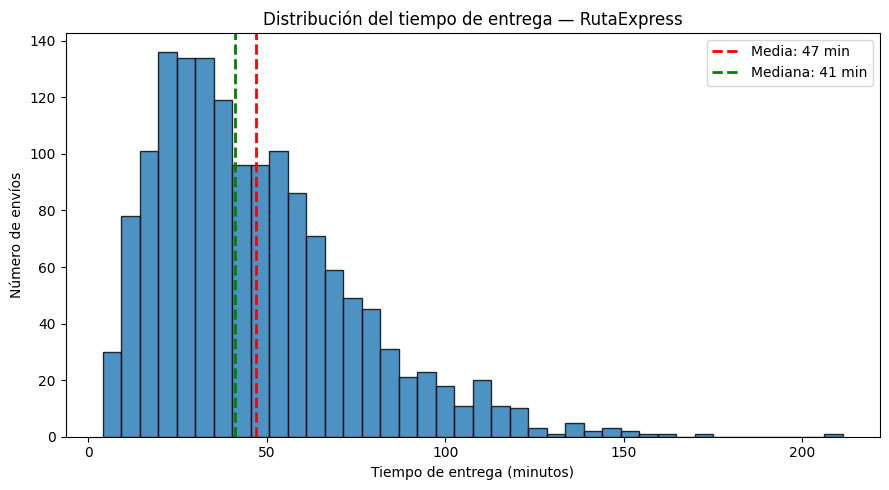

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["tiempo_entrega_min"], bins=40, color="#1f77b4", edgecolor="black", alpha=0.8)

media_tiempo = df["tiempo_entrega_min"].mean()
mediana_tiempo = df["tiempo_entrega_min"].median()
ax.axvline(media_tiempo, color="red", linestyle="--", linewidth=2, label=f"Media: {media_tiempo:,.0f} min")
ax.axvline(mediana_tiempo, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana_tiempo:,.0f} min")

ax.set_title("Distribución del tiempo de entrega — RutaExpress")
ax.set_xlabel("Tiempo de entrega (minutos)")
ax.set_ylabel("Número de envíos")
ax.legend()
plt.tight_layout()
plt.show()

> La distribución presenta una cola hacia la derecha, ya que la mayoría de los envíos se concentra en tiempos relativamente bajos, mientras que algunos envíos presentan tiempos considerablemente mayores.
Esto coincide con el sesgo positivo de 1.14 obtenido anteriormente y con que la media sea mayor que la mediana, indicando que los retrasos altos influyen en la distribución.

2. Construye, en un mismo gráfico, la densidad (KDE) de tiempo_entrega_min para dos zonas que tú elijas (por ejemplo, la de mejor y la de peor desempeño según la Parte C). ¿Qué diferencia visual encuentras entre ambas curvas, y qué decisión de negocio podrías sustentar con esa comparación?

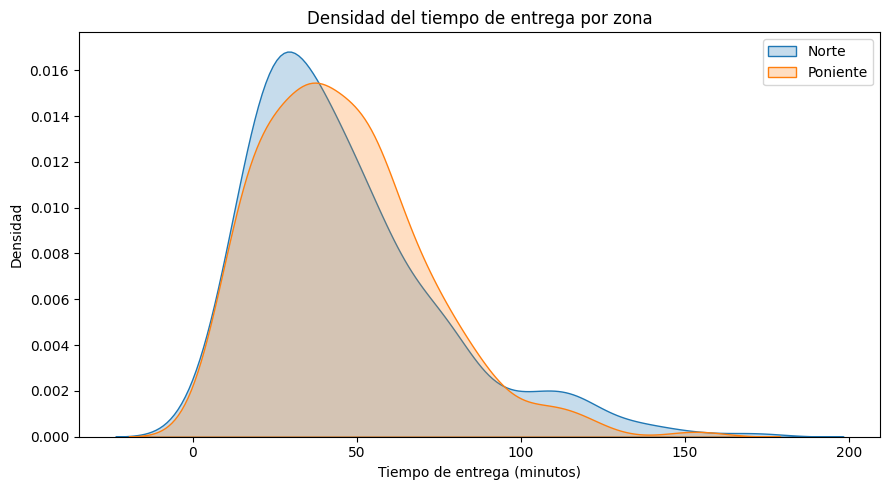

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(data=df[df["zona_entrega"] == "Norte"], x="tiempo_entrega_min", fill=True, label="Norte", ax=ax)

sns.kdeplot(data=df[df["zona_entrega"] == "Poniente"], x="tiempo_entrega_min", fill=True, label="Poniente", ax=ax)

ax.set_title("Densidad del tiempo de entrega por zona")
ax.set_xlabel("Tiempo de entrega (minutos)")
ax.set_ylabel("Densidad")
ax.legend()

plt.tight_layout()
plt.show()

>Las dos zonas presentan una distribución similar, con una concentración de los tiempos de entrega entre aproximadamente 20 y 70 minutos y una cola hacia la derecha. Sin embargo, Norte presenta una mayor dispersión y una cola más extendida hacia tiempos altos, mientras que Poniente concentra sus tiempos un poco más alrededor de valores cercanos a 40 minutos.

>Esta comparación sugiere que se debería prestar mayor atención a la variabilidad de los tiempos de entrega en la zona Norte. Aunque ambas zonas presentan comportamientos similares, la mayor dispersión de Norte puede indicar una mayor dificultad para mantener tiempos de entrega consistentes, por lo que sería conveniente analizar las causas de los tiempos extremos antes de establecer compromisos de servicio específicos para esta zona.

## **Parte F — Síntesis y decisión gerencial**
1. Redacta un memo ejecutivo de máximo 200 palabras, dirigido al Director de Operaciones de RutaExpress, en el que respondas las tres preguntas planteadas en la Sección 1 (expansión de drones, zona prioritaria, meta de SLA). Cada recomendación debe estar sustentada en al menos una medida descriptiva concreta que hayas calculado (no basta con opiniones generales).


>Recomendamos evaluar una expansión de la flota de drones, ya que presentan la mejor mediana de tiempo de entrega, con 19.75 minutos, muy por debajo de motocicletas (37.90) y automóviles (39.80). Sin embargo, esta expansión debería evaluarse según las zonas donde sea operativamente posible.

>La zona Norte debería ser priorizada para una intervención operativa, debido a que presenta el mayor coeficiente de variación (62.79%), aunque su tiempo promedio de 46.04 minutos es similar al de otras zonas. Esto indica que el principal problema es la poca consistencia del servicio.

>Para la comunicación pública, recomendamos una meta de 41 minutos, sustentada en la mediana del tiempo de entrega. Esta medida representa mejor el comportamiento típico que la media de 46.90 minutos, que está influenciada por entregas con tiempos elevados.

2. Menciona al menos una limitación de tu análisis que el Director debería tener en cuenta antes de tomar la decisión final (por ejemplo, relacionada con el tamaño de la muestra, variables que no están en el dataset, o el hecho de que este es solo un análisis descriptivo y no uno inferencial o causal).

>Una limitación importante es que el análisis es descriptivo y se basa en 1.500 envíos, por lo que permite identificar patrones, pero no establecer relaciones causales. Por ejemplo, aunque los drones presentan una menor mediana de tiempo, no podemos afirmar únicamente con estos datos que utilizar más drones sea la causa de mejores tiempos de entrega. Antes de tomar la decisión final sería conveniente considerar otras variables y realizar un análisis más profundo.